# modeles lineaires

In [54]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import SGDRegressor, LinearRegression, Ridge, RidgeCV, Lasso, ElasticNet
from sklearn.datasets import make_regression, make_circles
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

Text(0.5, 1.0, 'data')

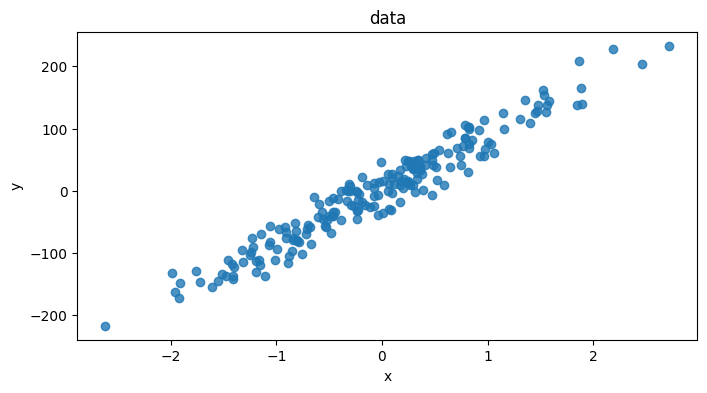

In [2]:
x, y = make_regression(n_samples=200, n_features=1, n_targets=1, noise=20, random_state=42)
plt.figure(figsize=(8, 4))
plt.scatter(x, y, alpha=0.8)
plt.xlabel("x")
plt.ylabel("y")
plt.title("data")

* SGDRegressor

In [3]:
model = SGDRegressor(loss="squared_error",
                     penalty="l2",
                     l1_ratio=0.15,
                     fit_intercept=True,
                     max_iter=1000,
                     tol=0.001,
                     learning_rate="invscaling",
                     eta0=0.01)
model.fit(x, y)
y_pred = model.predict(x)
model.score(x, y)

0.9413688940183329

Text(0.5, 1.0, 'SGDRegressor')

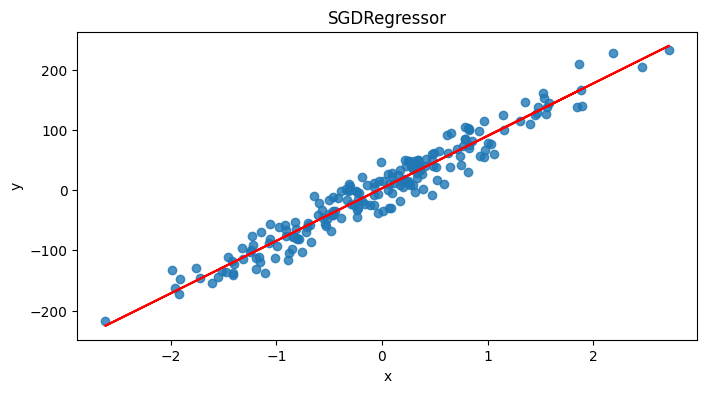

In [4]:
plt.figure(figsize=(8, 4))
plt.scatter(x, y, alpha=0.8)
plt.plot(x, y_pred, c="r")
plt.xlabel("x")
plt.ylabel("y")
plt.title("SGDRegressor")

* LinearRegressor

In [5]:
x, y = make_regression(n_samples=10000, n_features=2, noise=20, random_state=42)

In [6]:
model = LinearRegression(fit_intercept=True,
                         copy_X=True,
                         tol=1e-6)
model.fit(x, y)
y_pred = model.predict(x)
model.score(x, y)

0.9607720972452705

In [7]:
x1_min, x1_max = x[:,0].min()-1, x[:,0].max()+1
x2_min, x2_max = x[:,1].min()-1, x[:,1].max()+1

xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.2),
                       np.arange(x2_min, x2_max, 0.2))

grid = np.c_[xx1.ravel(), xx2.ravel()]
z = model.predict(grid)
Z = z.reshape(xx1.shape)
Z.shape

(47, 51)

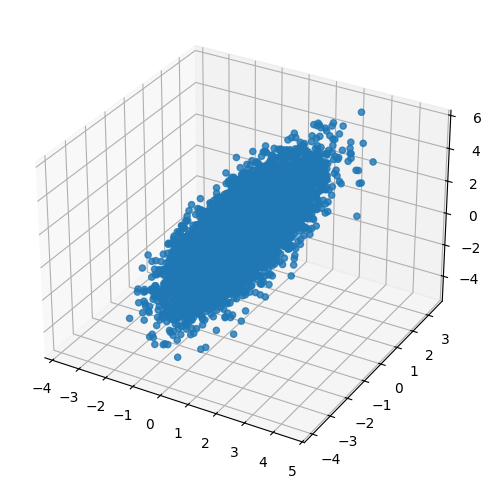

In [8]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection='3d')
z_plot = x[:,0] + x[:,1]
ax.scatter3D(x[:,0], x[:,1], z_plot, alpha=0.8)

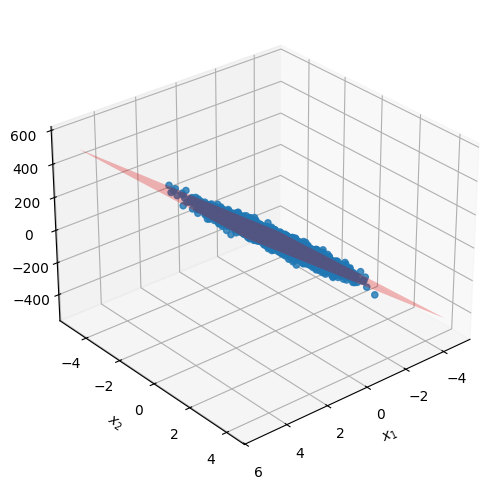

In [9]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection='3d')
ax.scatter3D(x[:,0], x[:,1], y, alpha=0.8)
ax.plot_surface(xx1, xx2, Z, color="r", alpha=0.3)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel("y")
# Change the viewpoint
ax.view_init(elev=29., azim=50.)

plt.show()

In [10]:
x, y = make_circles(n_samples=100, noise=0.05, random_state=0, factor=0.4)

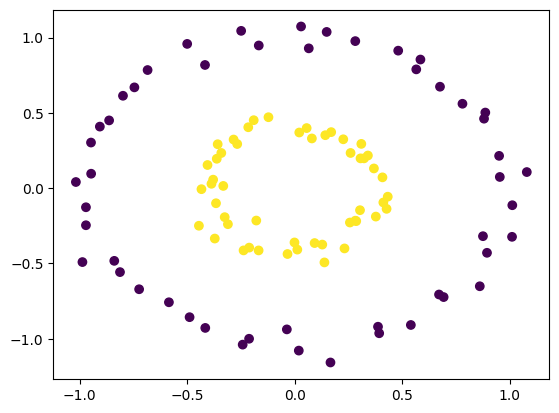

In [11]:
plt.scatter(x[:,0], x[:,1], c=y)

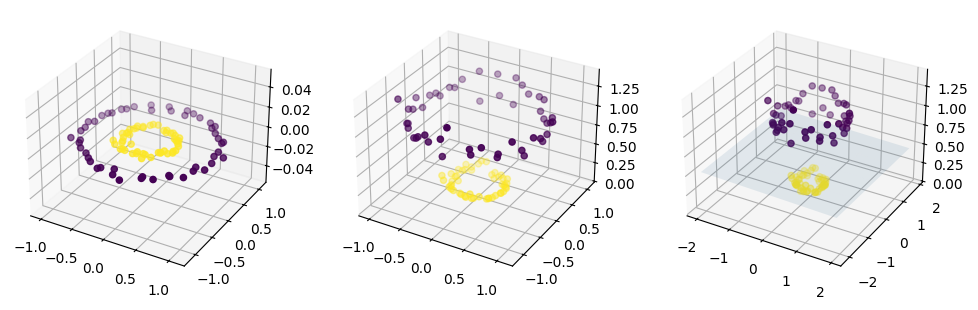

In [12]:
fig = plt.figure(figsize=(12, 4))

ax = fig.add_subplot(1, 3, 1, projection='3d')
ax.scatter3D(x[:,0], x[:,1], 0, c=y)

#to separate the data
z = x[:,0]**2 + x[:,1]**2
ax = fig.add_subplot(1, 3, 2, projection='3d')
ax.scatter3D(x[:,0], x[:,1], z, c=y)

#plot the plan
xx1, xx2 = np.meshgrid(np.arange(x[:,0].min()-1, x[:,0].max()+1),
                       np.arange(x[:,1].min()-1, x[:,1].max()+1)) 
grid = np.c_[xx1.ravel(), xx2.ravel()]

# model
linear_model = LinearRegression()
linear_model.fit(x, y)
z_pred = linear_model.predict(grid)
z_plot = z_pred.reshape(xx1.shape)
ax = fig.add_subplot(1, 3, 3, projection='3d')
ax.scatter3D(x[:,0], x[:,1], z, c=y)
ax.plot_surface(X=xx1, Y=xx2, Z=z_plot,alpha=0.1)



* SGDRegressor vs LinearRegressor - Comparaison des temps de calculs

Text(0.5, 1.0, 'data')

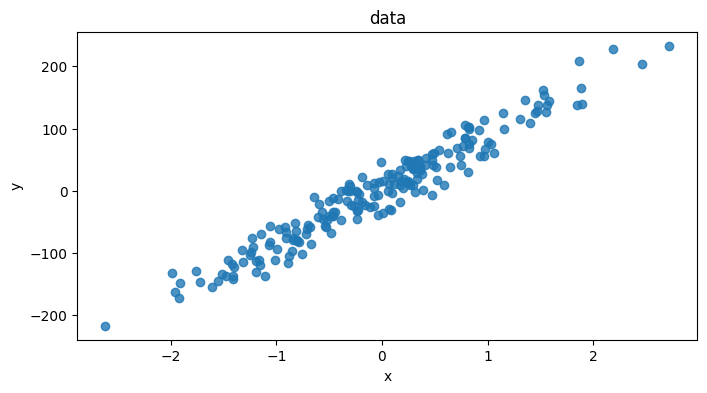

In [13]:
x, y = make_regression(n_samples=200, n_features=1, n_targets=1, noise=20, random_state=42)
plt.figure(figsize=(8, 4))
plt.scatter(x, y, alpha=0.8)
plt.xlabel("x")
plt.ylabel("y")
plt.title("data")

In [14]:
import time

def make_data(n_rows, n_cols):
    x, y = make_regression(n_samples=n_rows, n_features=n_cols, noise=20, random_state=42)
    return x, y

def train_model(model_name, x, y):
    model = model_name()
    start_time = time.time()
    model.fit(x, y)
    end_time = time.time() - start_time
    return model, end_time

def plot2cols(x, y, model1, model1_time, model2, model2_time):
    fig, ax = plt.subplots(1, 2, figsize=(12,4))
    ax[0].scatter(x, y)
    ax[0].plot(x, model1.predict(x), c="r")
    ax[0].set_title(f"{str(model1)} - score: {round(model1.score(x,y), 2)} - time: {round(model1_time, 2)}")
    ax[1].scatter(x, y)
    ax[1].plot(x, model2.predict(x), c="r")
    ax[1].set_title(f"{str(model2)} - score: {round(model2.score(x,y), 2)} - time: {round(model2_time, 2)}")
    
def sgd_vs_linear(n_rows, n_cols):
    #generate data
    x, y = make_data(n_rows, n_cols)
    
    #train SGDRegressor
    sgd, sgd_time = train_model(SGDRegressor, x, y)
    
    #train linearRegressor
    lin, lin_time = train_model(LinearRegression, x, y)
    
    print(f"SGD time: {round(sgd_time, 2)} - LinearRegressor time: {round(lin_time, 2)}")
    
    #plot 2 models
    #plot2cols(x, y, sgd, sgd_time, lin, lin_time)

In [15]:
sgd_vs_linear(n_rows=10000, n_cols=10)

SGD time: 0.01 - LinearRegressor time: 0.0


In [16]:
sgd_vs_linear(n_rows=10000, n_cols=100)

SGD time: 0.16 - LinearRegressor time: 0.04


In [17]:
sgd_vs_linear(n_rows=10000, n_cols=1000)

SGD time: 2.9 - LinearRegressor time: 1.42


In [18]:
sgd_vs_linear(n_rows=1000000, n_cols=100)

SGD time: 29.88 - LinearRegressor time: 4.96


* PolynomialeRegresson

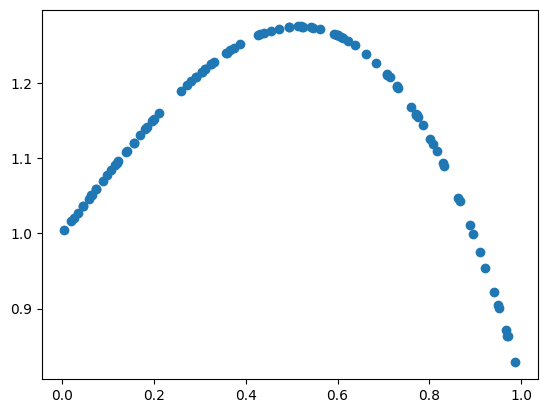

In [35]:
np.random.seed(42)
x = np.random.rand(100, 1)
y = 1 - x**3 + 0.8*x
plt.scatter(x,y)

In [21]:
model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)
model.fit(x, y)
model.score(x, y)

0.9724204507318377

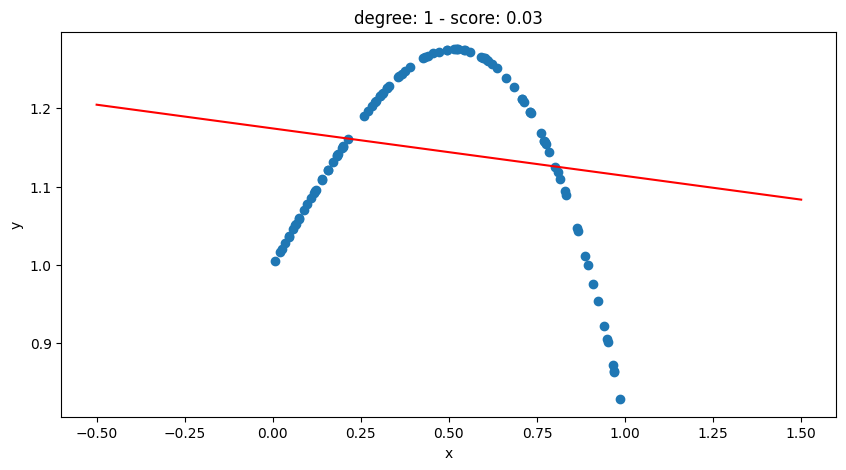

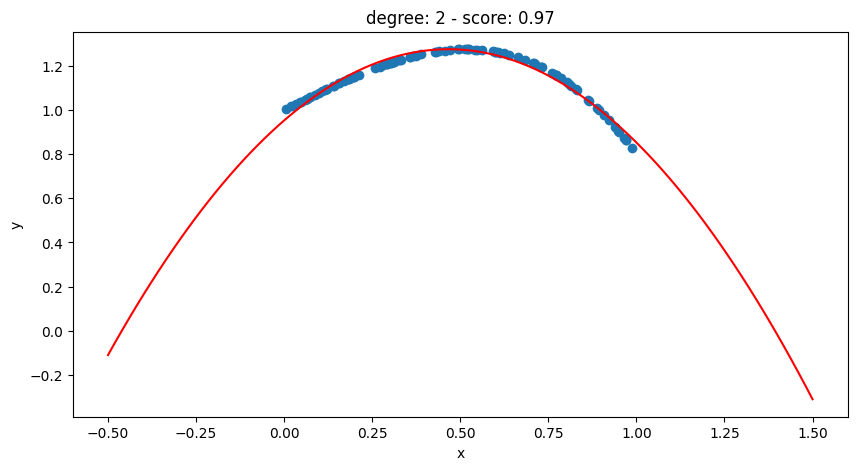

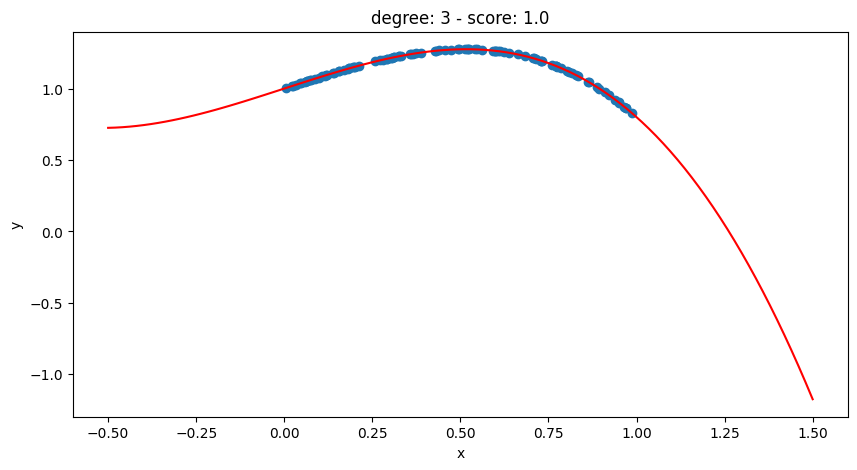

In [22]:
for n_degree in range(1, 4):
    model = make_pipeline(
        PolynomialFeatures(degree=n_degree),
        LinearRegression()
    )
    model.fit(x, y)
    x_plot = np.linspace(-0.5, 1.5, 100).reshape(-1, 1)
    y_plot = model.predict(x_plot)
    fig = plt.figure(figsize=(10, 5))
    plt.scatter(x,y)
    plt.plot(x_plot, y_plot, c="r")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"degree: {n_degree} - score: {round(model.score(x, y), 2)}")

* regularisation

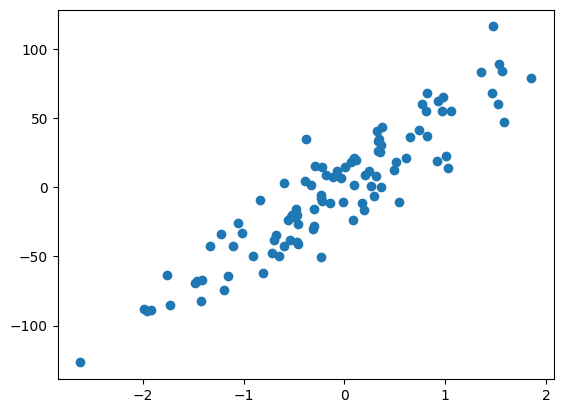

In [23]:
x, y = make_regression(n_samples=100, n_features=1, noise=20, random_state=42)
plt.scatter(x, y)

Ridge

In [32]:
ridge = Ridge(alpha=1)
ridge.fit(x,y)
y_pred_ridge = ridge.predict(x)
ridge.score(x, y)

0.8530293199547445

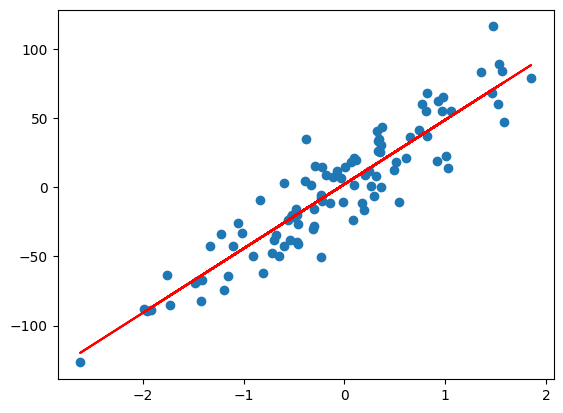

In [33]:
plt.scatter(x, y)
plt.plot(x, y_pred_ridge, c="r")

RidgeCV

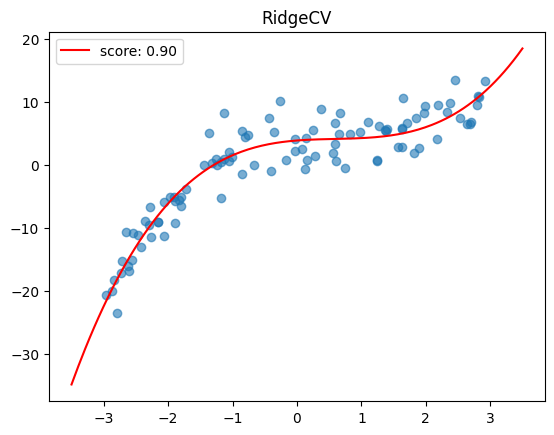

In [75]:
np.random.seed(42)
n_samples = 100
X = np.sort(np.random.rand(n_samples, 1) * 6 - 3, axis=0)
y = 0.5 * X**3 - X**2 + X + np.random.randn(n_samples, 1) * 3
y = y - y.mean()  # centrage de y


#model
ridge_cv = make_pipeline(
    PolynomialFeatures(degree=3),
    RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], scoring='r2', cv=5)
)
ridge_cv.fit(X, y)
score = ridge_cv.score(X,y)

x_plot = np.linspace(-3.5, 3.5, 200).reshape((-1, 1))
y_plot = ridge_cv.predict(x_plot)

plt.scatter(X, y, alpha=0.6)
plt.plot(x_plot, y_plot, label=f"score: {score:.2f}", c="r")
plt.title("RidgeCV")
plt.legend()

Lasso

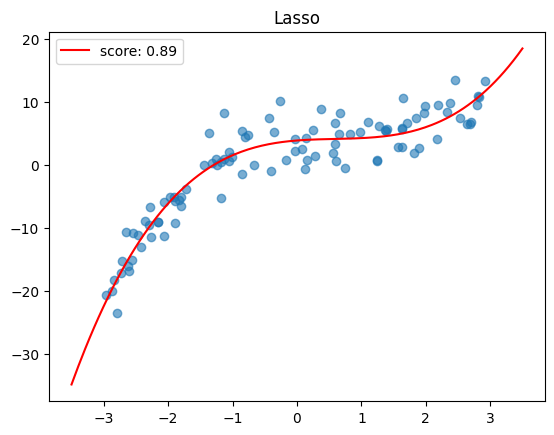

In [76]:
np.random.seed(42)
n_samples = 100
X = np.sort(np.random.rand(n_samples, 1) * 6 - 3, axis=0)
y = 0.5 * X**3 - X**2 + X + np.random.randn(n_samples, 1) * 3
y = y - y.mean()  # centrage de y


#model
lasso = make_pipeline(
    PolynomialFeatures(degree=3),
    Lasso()
)
lasso.fit(X, y)
score = lasso.score(X,y)

x_plot = np.linspace(-3.5, 3.5, 200).reshape((-1, 1))
y_plot = ridge_cv.predict(x_plot)

plt.scatter(X, y, alpha=0.6)
plt.plot(x_plot, y_plot, label=f"score: {score:.2f}", c="r")
plt.title("Lasso")
plt.legend()


ElasticNet

Text(0, 0.5, 'y')

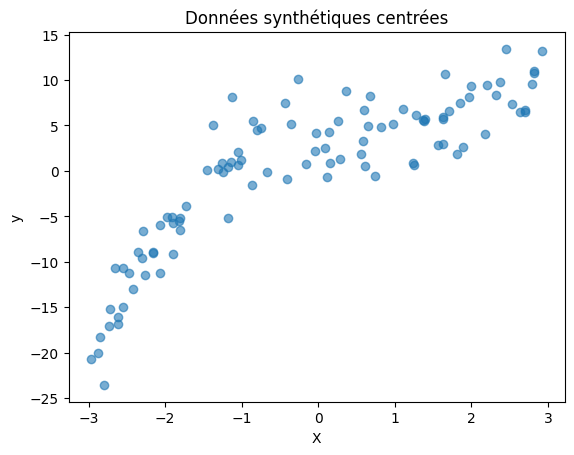

In [38]:
np.random.seed(42)
n_samples = 100
X = np.sort(np.random.rand(n_samples, 1) * 6 - 3, axis=0)
y = 0.5 * X**3 - X**2 + X + np.random.randn(n_samples, 1) * 3
y = y - y.mean()  # centrage de y

plt.scatter(X, y, alpha=0.6)
plt.title("Données synthétiques centrées")
plt.xlabel("X")
plt.ylabel("y")

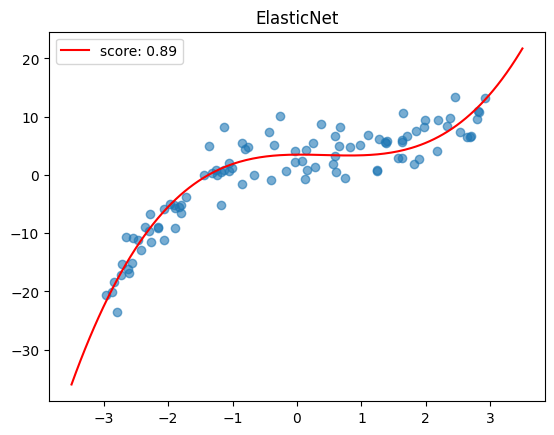

In [ ]:
elastic = make_pipeline(
    PolynomialFeatures(degree=3),
    ElasticNet(alpha=1, l1_ratio=0.5)
)
elastic.fit(X, y)
score = elastic.score(X, y)

#model coordinates
x_plot = np.linspace(-3.5, 3.5, 200).reshape((-1, 1))
y_plot = elastic.predict(x_plot)

#plotting model
plt.scatter(X, y, alpha=0.6)
plt.plot(x_plot, y_plot, c="r", label=f"score: {score:.2f}")
plt.title("ElasticNet")
plt.legend()